# Mooloolaba Wave Height Data: Unification and Cleaning (2015-2025)

This notebook downloads, combines, and cleans wave buoy data for Mooloolaba, Queensland, from 2015 to 2025. The data is sourced from the Queensland Government's open data portal.

**Objective:** To create a single, clean, and analysis-ready time series dataset from multiple yearly CSV files.

**Steps:**
1.  **Download Data**: Programmatically fetch the CSV file for each year from 2015 to 2025 using a predefined list of URLs.
2.  **Load & Combine**: Read each CSV into a pandas DataFrame and concatenate them into a single master DataFrame.
    - Parse dates and times into a proper datetime format.
3.  **Clean & Preprocess**: 
    - Standardize column names.
    - Check for and handle missing values.
    - Set a proper time series index.
4.  **Basic EDA**: Perform a quick visual inspection of the combined data to ensure correctness.
5.  **Export**: Save the final, unified dataset to a single CSV file.

### Step 1: Import Libraries and Define Parameters

In [33]:
import pandas as pd
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

# --- Parameters ---
# The data source URLs are not always sequential, so we will define them individually.
DATA_URLS = {
    2015: "https://data.des.qld.gov.au/__data/assets/file/0027/92385/mooloolaba-201501010000-201512312350.csv",
    2016: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/8e7fcf48-ac17-45ea-b4f3-b30cd1739658/download/mool201601010000-201612312350correctedmasterdata.csv",
    2017: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/61faa02e-a4e5-400e-98ff-3266b255da1b/download/mooloolaba_2017-01-01t00_00-2017-12-31t23_30.csv",
    2018: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/b92629f7-a79f-45a2-857d-2217b2f11e63/download/mooloolaba_2018-01-01t00_00-2018-12-31t23_30.csv",
    2019: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/d80243cd-5bca-41a0-b0f8-4d4fac168d94/download/mooloolaba_verifieddata.csv",
    2020: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/f58445e2-44cc-48e6-ad99-1ee56e1ee402/download/mooloolaba_2020-01-01t00_00-2020-12-31t23_30.csv",
    2021: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/b700d6d6-31fa-43b1-ae89-1fa811765aff/download/mooloolaba_2021-01-01t00_00-2021-12-31t23_30_waveverifieddata.csv",
    2022: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/c995189b-82ec-422b-bf56-ccc5510618bc/download/mooloolaba_2022-01-01t00_00-2022-12-31t23_30_waveverifieddata.csv",
    2023: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/fbad2855-d2cb-4889-ba1e-bee2c042d1c2/download/mooloolaba_2023-01-01t00_00-2023-12-31t23_30_waveverifieddata.csv",
    2024: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/51c8f862-5ecd-4cff-af35-968ddd48a16e/download/mooloolaba_2024-01-01t00_00-2024-12-31t23_30_waveverifieddata.csv",
    2025: "https://www.data.qld.gov.au/dataset/aafb52d6-7bb8-4601-966b-5153bd35d4f8/resource/c0cfd5c8-59c1-4fcf-b9d9-75bce4149808/download/mooloolaba_2025-01-01t00_00-2025-03-31t23_30_waveverifieddata.csv"
}

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

### Step 2: Download and Combine Data

In [34]:
all_years_data = []

print(f"Downloading data for years: {list(DATA_URLS.keys())}...")

for year, file_url in DATA_URLS.items():
    print(f"\nFetching data for {year}...")
    try:
        # Make a request to download the file
        response = requests.get(file_url)
        response.raise_for_status() # Raise an exception for bad status codes (404, 500, etc.)

        # We also need to specify the encoding.
        df_year = pd.read_csv(io.StringIO(response.text), encoding='latin1')

        # Column names changed in 2017 and 2022
        if year < 2017:
            df_year.rename(
                columns={'Dir_Tp TRUE': 'Peak Direction'},
                inplace=True
            )
        if year > 2021:
            col_name_map = {
                col_name : col_name.split(' (')[0] for col_name in df_year.columns
            }
            df_year.rename(columns=col_name_map, inplace=True)

        # Convert Date/Time column to datetime objects
        df_year['Date/Time'] = pd.to_datetime(df_year['Date/Time'], errors='raise')
        print("Converted Date/Time to datetime")
        
        # Add a 'Year' column for verification before appending
        # df_year['Year'] = year
        all_years_data.append(df_year)
        print(f"Successfully downloaded and preprocessed data for {year}.")

    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 404:
            print(f"Data for {year} not found at {file_url}. Skipping.")
        else:
            print(f"HTTP Error for {year}: {e}")
    except Exception as e:
        print(f"An error occurred while processing data for {year}: {e}")

# Concatenate all the yearly dataframes into one
if all_years_data:
    wave_df = pd.concat(all_years_data, ignore_index=True)
    print("\nAll yearly data has been combined into a single DataFrame.")
    display(wave_df.head())
    display(wave_df.tail())
else:
    print("\nNo data was downloaded. Cannot proceed.")


Fetching data for 2015...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2015.

Fetching data for 2016...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2016.

Fetching data for 2017...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2017.

Fetching data for 2018...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2018.

Fetching data for 2019...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2019.

Fetching data for 2020...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2020.

Fetching data for 2021...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2021.

Fetching data for 2022...
Converted Date/Time to datetime
Successfully downloaded and preprocessed data for 2022.

Fetching data for 2023...
Converted Date/Time to datetime
Successfully download

,Date/Time,Hs,Hmax,Tz,Tp,Peak Direction,SST
0,2015-01-01 00:00:00,1.1364,2.08,6.6727,9.3271,97.0,26.95
1,2015-01-01 00:30:00,1.1240,1.92,6.3688,10.1230,92.0,26.90
2,2015-01-01 01:00:00,1.2728,2.07,6.6257,10.2040,90.0,26.90
3,2015-01-01 01:30:00,1.2310,1.85,6.6525,9.7295,99.0,26.90
4,2015-01-01 02:00:00,1.1512,2.00,6.0310,10.3206,84.0,26.90


,Date/Time,Hs,Hmax,Tz,Tp,Peak Direction,SST
179399,2025-03-31 21:30:00,1.094,1.76,4.972,8.146,125.0,26.20
179400,2025-03-31 22:00:00,1.150,1.84,5.215,8.826,120.0,26.15
179401,2025-03-31 22:30:00,1.209,2.34,5.344,8.173,108.0,26.10
179402,2025-03-31 23:00:00,1.231,2.17,4.924,8.509,99.0,26.10
179403,2025-03-31 23:30:00,1.257,2.35,4.993,8.743,-99.9,-99.90


### Step 3: Clean and Preprocess the Data

Now that we have a single DataFrame, we need to clean it up for analysis.

In [37]:
if 'wave_df' in locals():
    # --- 1. Inspect Columns and Data Types ---
    print("--- Initial Info ---")
    wave_df.info()
    
    # --- 2. Rename Columns for Clarity ---
    # Create a mapping of old names to new, more convenient names
    column_map = {
        'Date/Time': 'datetime_aest',
        'Hs': 'hsig_m',
        'Hmax': 'hmax_m',
        'Tz': 'tz_s',
        'Tp': 'tp_s',
        'Peak Direction': 'peak_dir_deg',
        'SST': 'sst_c'
    }
    wave_df.rename(columns=column_map, inplace=True)
    print("\n--- Columns Renamed ---")

    # instead perform this conversion on each year's data individually, due to inconsistent formats
    # # --- 3. Convert to Datetime Objects ---
    # # Convert the datetime column to a proper datetime format, errors='coerce' will turn failures into NaT (Not a Time)
    # wave_df['datetime_aest'] = pd.to_datetime(wave_df['datetime_aest'], errors='coerce')
    # print("\n--- Converted 'datetime_aest' column to datetime objects ---")

    # --- 4. Handle Missing or Bad Data ---
    # Drop rows where the datetime conversion failed
    initial_rows = len(wave_df)
    wave_df.dropna(subset=['datetime_aest'], inplace=True)
    if initial_rows > len(wave_df):
        print(f"Dropped {initial_rows - len(wave_df)} rows with invalid dates.")
        
    # Check for missing values in the key measurement columns
    print("\n--- Missing Values Count ---")
    print(wave_df[['hsig_m', 'hmax_m', 'tz_s', 'tp_s']].isnull().sum())
    
    # For this analysis, we will leave missing numeric values as NaN. 
    # One could also interpolate or fill them, but that depends on the specific use case.
    
    # --- 5. Set Datetime as Index ---
    wave_df.set_index('datetime_aest', inplace=True)
    # Sort the index to ensure the time series is in chronological order
    wave_df.sort_index(inplace=True)
    
    print("\n--- Final DataFrame Info ---")
    wave_df.info()
    
    print("\n--- Cleaned DataFrame Head ---")
    display(wave_df.head())


--- Initial Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179404 entries, 0 to 179403
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date/Time       179404 non-null  datetime64[ns]
 1   Hs              179404 non-null  float64       
 2   Hmax            179404 non-null  float64       
 3   Tz              179404 non-null  float64       
 4   Tp              179404 non-null  float64       
 5   Peak Direction  179404 non-null  float64       
 6   SST             179404 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 9.6 MB

--- Columns Renamed ---

--- Missing Values Count ---
hsig_m    0
hmax_m    0
tz_s      0
tp_s      0
dtype: int64

--- Final DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 179404 entries, 2015-01-01 00:00:00 to 2025-03-31 23:30:00
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  

,hsig_m,hmax_m,tz_s,tp_s,peak_dir_deg,sst_c
datetime_aest,,,,,,
2015-01-01 00:00:00,1.1364,2.08,6.6727,9.3271,97.0,26.95
2015-01-01 00:30:00,1.1240,1.92,6.3688,10.1230,92.0,26.90
2015-01-01 01:00:00,1.2728,2.07,6.6257,10.2040,90.0,26.90
2015-01-01 01:30:00,1.2310,1.85,6.6525,9.7295,99.0,26.90
2015-01-01 02:00:00,1.1512,2.00,6.0310,10.3206,84.0,26.90


### Step 4: Basic Exploratory Data Analysis (EDA)

Let's create a quick plot of the significant wave height (`Hsig`) over the entire period to visually inspect the data for large gaps or anomalies.

Plotting significant wave height (Hsig) from 2015-2025...


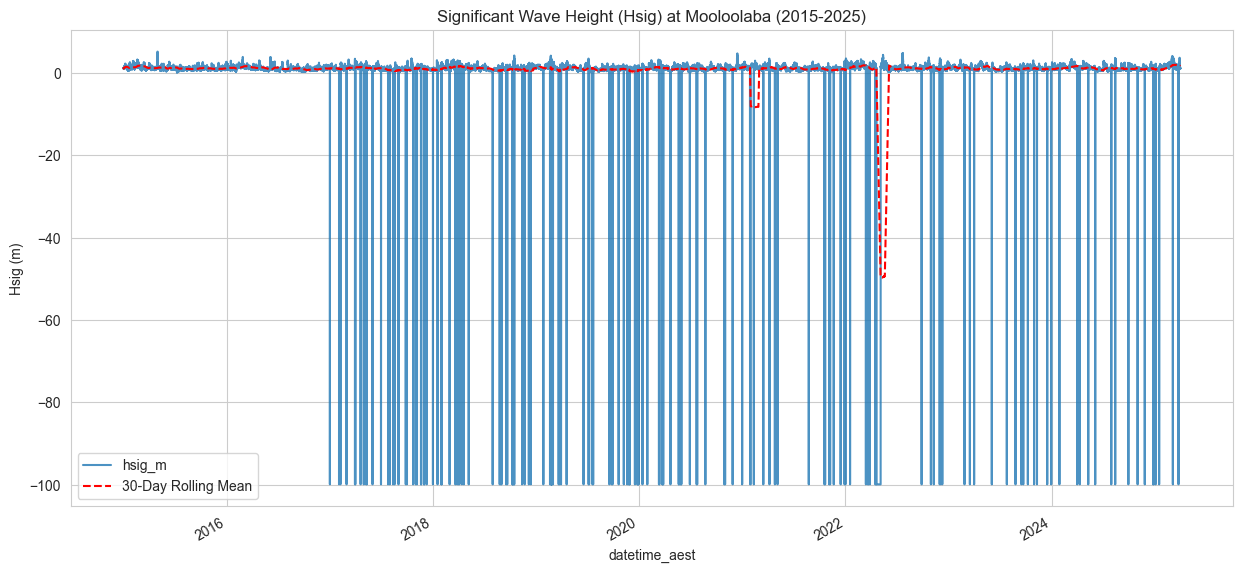


--- Summary Statistics for Wave Height ---


count    179404.000000
mean          0.618247
std           7.781178
min         -99.900000
25%           0.841000
50%           1.106000
75%           1.486000
max           5.203600
Name: hsig_m, dtype: float64

In [38]:
if 'wave_df' in locals():
    print("Plotting significant wave height (Hsig) from 2015-2025...")
    
    ax = wave_df['hsig_m'].plot(
        title='Significant Wave Height (Hsig) at Mooloolaba (2015-2025)',
        ylabel='Hsig (m)',
        xlabel='Date',
        alpha=0.8
    )
    
    # Add a rolling mean to see the trend more clearly
    wave_df['hsig_m'].rolling(window='30D').mean().plot(
        ax=ax, 
        color='red', 
        linestyle='--',
        label='30-Day Rolling Mean'
    )
    
    plt.legend()
    plt.show()
    
    # Show summary statistics
    print("\n--- Summary Statistics for Wave Height ---")
    display(wave_df['hsig_m'].describe())


### Step 5: Save the Unified Dataset

Finally, we'll save our cleaned and combined DataFrame to a single CSV file in the Kaggle output directory (`/kaggle/working/`).

In [39]:
if 'wave_df' in locals():
    output_filename = 'mooloolaba_wave_data_2015-2025.csv'
    
    # The index is our datetime, so we want to save it with the CSV
    wave_df.to_csv(output_filename, index=True)
    
    print(f"Successfully saved the unified dataset to '{output_filename}'")
    print("You can find this file in the 'Output' section of the Kaggle Data panel.")

Successfully saved the unified dataset to 'mooloolaba_wave_data_2015-2025.csv'
You can find this file in the 'Output' section of the Kaggle Data panel.
